# HR Candidate Segmentation with Clustering

## Project Overview

This project applies unsupervised machine learning techniques to identify groups of candidates with similar characteristics within an HR dataset.

The analysis uses K-Means and Agglomerative Clustering to explore underlying structure in the data. Feature scaling, cluster-center analysis, the elbow method, dendrograms, and visualizations are used to evaluate and interpret the resulting candidate segments.

## Objectives

- Explore the structure and quality of the HR dataset
- Prepare numerical features for distance-based clustering
- Standardize features to ensure comparable scales
- Apply K-Means clustering
- Interpret cluster centers and candidate characteristics
- Use the elbow method to investigate the number of clusters
- Apply Agglomerative Clustering
- Visualize hierarchical relationships using a dendrogram
- Compare clustering solutions and identify meaningful candidate segments

## 1. Data Loading and Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("hrdata3.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (12977, 8)


,Unnamed: 0,enrollee_id,city_development_index,experience,company_size,last_new_job,training_hours,target
0,1,29725,0.776,15,2,5,47,0.0
1,4,666,0.767,21,2,4,8,0.0
2,6,28806,0.920,5,2,1,24,0.0
3,7,402,0.762,13,0,5,18,1.0
4,8,27107,0.920,7,2,1,46,1.0


In [3]:
print("First 5 Rows:")
display(df.head())

print("Last 5 Rows:")
display(df.tail())

First 5 Rows:


,Unnamed: 0,enrollee_id,city_development_index,experience,company_size,last_new_job,training_hours,target
0,1,29725,0.776,15,2,5,47,0.0
1,4,666,0.767,21,2,4,8,0.0
2,6,28806,0.920,5,2,1,24,0.0
3,7,402,0.762,13,0,5,18,1.0
4,8,27107,0.920,7,2,1,46,1.0


Last 5 Rows:


,Unnamed: 0,enrollee_id,city_development_index,experience,company_size,last_new_job,training_hours,target
12972,19149,251,0.920,9,2,1,36,1.0
12973,19150,32313,0.920,10,3,3,23,0.0
12974,19152,29754,0.920,7,1,1,25,0.0
12975,19155,24576,0.920,21,2,4,44,0.0
12976,19156,5756,0.802,0,4,2,97,0.0


In [4]:
print("Missing Values:")
display(df.isnull().sum())

Missing Values:


Unnamed: 0                0
enrollee_id               0
city_development_index    0
experience                0
company_size              0
last_new_job              0
training_hours            0
target                    0
dtype: int64

In [5]:
print("Feature Data Types:")
display(df.dtypes)

Feature Data Types:


Unnamed: 0                  int64
enrollee_id                 int64
city_development_index    float64
experience                  int64
company_size                int64
last_new_job                int64
training_hours              int64
target                    float64
dtype: object

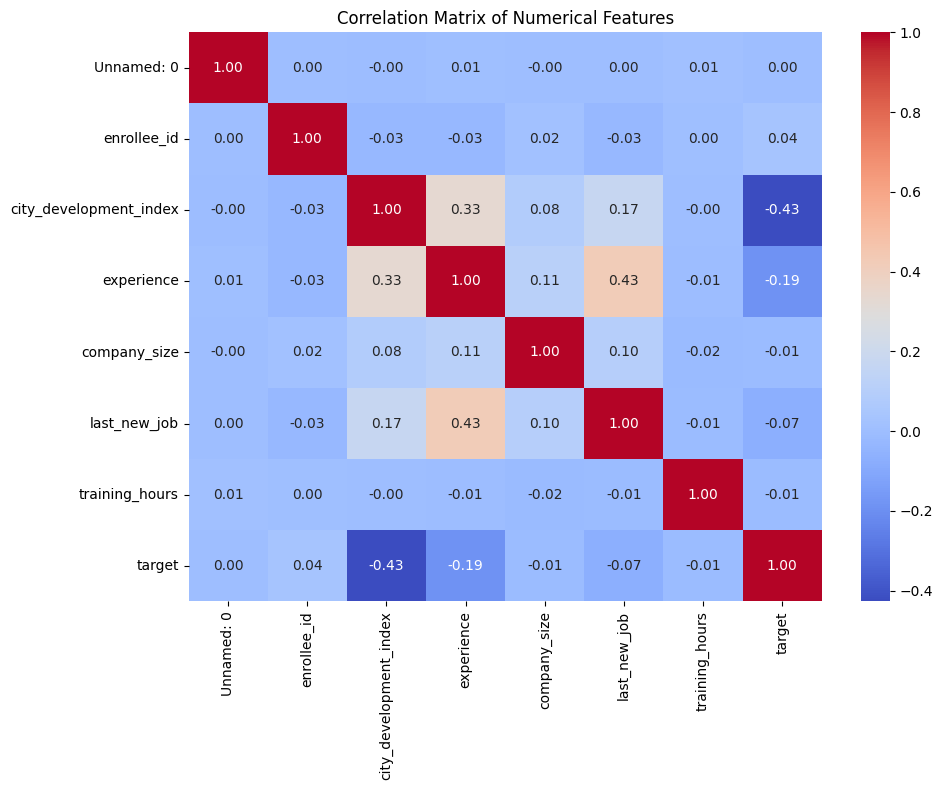

In [6]:
plt.figure(figsize=(10, 8))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

### Correlation Analysis

The correlation matrix helps identify relationships among the numerical features before clustering.

Because clustering is an unsupervised learning task, correlation is not being used to determine which variables predict the target. Instead, it provides context about the structure of the feature space and helps identify variables that may contain overlapping information.

Strongly correlated features can influence distance-based clustering because they may give similar information additional weight. For that reason, correlation should be considered when selecting features for K-Means and hierarchical clustering.

## 2. Feature Selection and Preprocessing

In [7]:
X = df.drop(
    columns=[
        "Unnamed: 0",
        "enrollee_id",
        "target"
    ]
)

print("Features used for clustering:")
print(X.columns.tolist())

print("\nFeature matrix shape:", X.shape)

Features used for clustering:
['city_development_index', 'experience', 'company_size', 'last_new_job', 'training_hours']

Feature matrix shape: (12977, 5)


### Feature Selection

`Unnamed: 0` is excluded because it represents a saved row index rather than a meaningful candidate characteristic.

`enrollee_id` is also excluded because it is a unique identifier and does not describe candidate behavior or background.

The `target` variable is excluded from the clustering feature set because clustering is an unsupervised learning technique. The algorithms should discover groups based only on candidate characteristics rather than using known class labels.

The target is examined only after clustering to explore whether the discovered candidate segments show different job-change behavior.

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns,
    index=X.index
)

display(X_scaled_df.head())

print("\nScaled feature means:")
display(X_scaled_df.mean().round(3))

print("Scaled feature standard deviations:")
display(X_scaled_df.std().round(3))

,city_development_index,experience,company_size,last_new_job,training_hours
0,-0.503422,0.633957,-0.574723,1.690762,-0.308396
1,-0.578413,1.546009,-0.574723,1.081137,-0.951805
2,0.696434,-0.886130,-0.574723,-0.747739,-0.687842
3,-0.620075,0.329940,-1.488268,1.690762,-0.786828
4,0.696434,-0.582112,-0.574723,-0.747739,-0.324894



Scaled feature means:


city_development_index    0.0
experience               -0.0
company_size             -0.0
last_new_job              0.0
training_hours           -0.0
dtype: float64

Scaled feature standard deviations:


city_development_index    1.0
experience                1.0
company_size              1.0
last_new_job              1.0
training_hours            1.0
dtype: float64

### Feature Scaling

The features are standardized using `StandardScaler` before clustering.

This step is particularly important for K-Means and Ward hierarchical clustering because both methods rely on distances between observations. Without scaling, features with larger numerical ranges could disproportionately influence the clustering results.

Standardization transforms the features so that they are centered around zero and have approximately unit variance, allowing each feature to contribute more comparably to the distance calculations.

## 3. K-Means Clustering

In [9]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=2,
    init="k-means++",
    random_state=47,
    n_init=10
)

kmeans.fit(X_scaled)

print("K-Means inertia:", round(kmeans.inertia_, 2))

K-Means inertia: 49643.79


/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: 

In [10]:
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)

cluster_centers = pd.DataFrame(
    centers_original,
    columns=X.columns
)

cluster_centers.index = [
    f"Cluster {i}"
    for i in range(len(cluster_centers))
]

display(cluster_centers.round(2))

,city_development_index,experience,company_size,last_new_job,training_hours
Cluster 0,0.89,16.75,3.72,3.49,64.89
Cluster 1,0.80,6.61,2.93,1.33,66.27


### Cluster Interpretation

The cluster centers provide a profile of the typical candidate within each group.

**Cluster 0** generally represents candidates from moderately developed cities with lower experience, smaller company sizes, more recent job changes, and somewhat higher training hours. This cluster appears to represent relatively less-experienced or earlier-career candidates.

**Cluster 1** generally represents candidates from more developed cities with greater experience, larger company sizes, longer periods since their last job change, and slightly lower training hours. This cluster appears to represent more experienced and established candidates.

These descriptions are based on differences in the cluster centers and should be interpreted as general patterns rather than strict categories.

In [11]:
df["kmeans_cluster"] = kmeans.labels_

print("Number of candidates in each K-Means cluster:")
display(
    df["kmeans_cluster"]
    .value_counts()
    .sort_index()
    .rename("Candidate Count")
    .to_frame()
)

Number of candidates in each K-Means cluster:


,Candidate Count
kmeans_cluster,
0,5401
1,7576


In [12]:
profile_features = [
    "city_development_index",
    "experience",
    "company_size",
    "last_new_job",
    "training_hours"
]

kmeans_profile = (
    df.groupby("kmeans_cluster")[profile_features]
    .mean()
    .round(2)
)

display(kmeans_profile)

,city_development_index,experience,company_size,last_new_job,training_hours
kmeans_cluster,,,,,
0,0.89,16.75,3.72,3.49,64.86
1,0.80,6.61,2.93,1.33,66.29


In [13]:
cluster_summary = (
    df.groupby("kmeans_cluster")
    .agg(
        Candidate_Count=("kmeans_cluster", "size"),
        Job_Change_Rate=("target", "mean")
    )
)

cluster_summary["Job_Change_Rate"] = (
    cluster_summary["Job_Change_Rate"] * 100
).round(1)

cluster_summary = cluster_summary.rename(
    columns={"Job_Change_Rate": "Job Change Rate (%)"}
)

display(cluster_summary)

,Candidate_Count,Job Change Rate (%)
kmeans_cluster,,
0,5401,9.9
1,7576,23.1


### Candidate Segment Profiles

The cluster profile summarizes the average characteristics of candidates assigned to each K-Means cluster.

These averages help translate the mathematical cluster assignments into more interpretable candidate segments. Differences in experience, company size, time since the last job change, city development, and training hours can be used to describe the general characteristics of each group.

The job-change rate is examined separately as an external characteristic of each cluster. Because `target` was not used to construct the clusters, differences in this rate help show whether the independently discovered candidate segments also differ in their interest in changing jobs.

In [14]:
display(
    df[
        [
            "experience",
            "training_hours",
            "city_development_index",
            "kmeans_cluster"
        ]
    ].head()
)

,experience,training_hours,city_development_index,kmeans_cluster
0,15,47,0.776,0
1,21,8,0.767,0
2,5,24,0.920,1
3,13,18,0.762,0
4,7,46,0.920,1


In [15]:
cluster_target_distribution = pd.crosstab(
    df["kmeans_cluster"],
    df["target"],
    normalize="index"
)

print("Target distribution within each K-Means cluster:")
display(cluster_target_distribution.round(3))

Target distribution within each K-Means cluster:


target,0.0,1.0
kmeans_cluster,,
0,0.901,0.099
1,0.769,0.231


### Relationship Between Clusters and Job-Change Target

The existing `target` variable was not used when creating the clusters. Instead, it is examined afterward to determine whether the candidate segments discovered by K-Means differ in their job-change behavior.

The target distribution within each cluster can reveal whether one candidate segment contains a larger proportion of individuals interested in changing jobs.

However, cluster labels should not be interpreted as predicted class labels. Cluster 0 and Cluster 1 are arbitrary identifiers assigned by K-Means, so classification accuracy, confusion matrices, and misclassification counts are not appropriate measures of clustering performance.

### Selecting the Number of Clusters

The elbow method evaluates how K-Means inertia changes as the number of clusters increases.

Inertia measures the total squared distance between observations and their assigned cluster centers. Lower inertia indicates that observations are grouped more tightly within their clusters.

Because inertia naturally decreases as more clusters are added, the goal is not simply to choose the value of `k` with the lowest inertia. Instead, the elbow method looks for a point where adding additional clusters produces diminishing improvements.

To complement the elbow method, silhouette scores are also evaluated. The silhouette score considers both how closely observations are grouped within their own cluster and how well separated they are from neighboring clusters. Higher silhouette scores generally indicate more clearly defined clusters.

In [16]:
from sklearn.metrics import silhouette_score

k_values = range(2, 11)

inertia_values = []
silhouette_scores = []

for k in k_values:
    km = KMeans(
        n_clusters=k,
        init="k-means++",
        random_state=47,
        n_init=10
    )

    cluster_labels = km.fit_predict(X_scaled)

    inertia_values.append(km.inertia_)

    silhouette_scores.append(
        silhouette_score(
            X_scaled,
            cluster_labels
        )
    )

/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: 

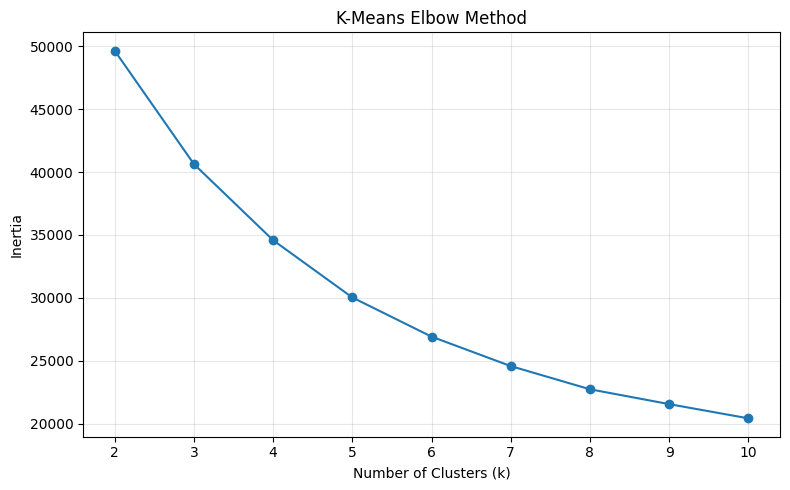

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    inertia_values,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("K-Means Elbow Method")
plt.xticks(list(k_values))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

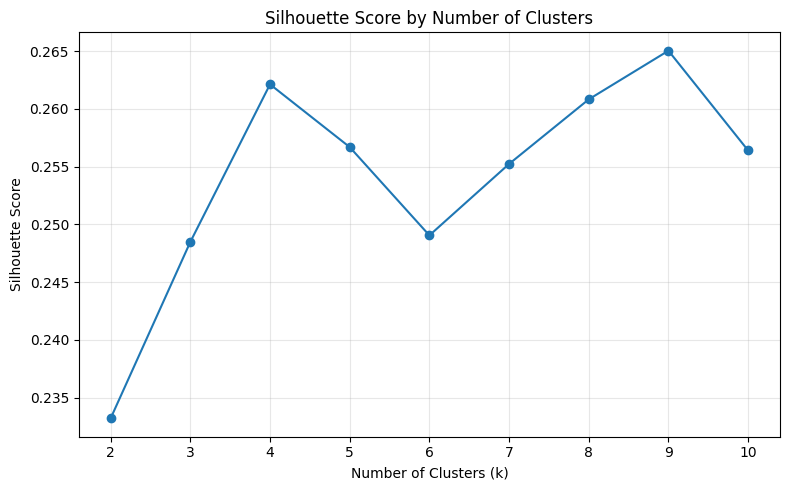

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")
plt.xticks(list(k_values))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
cluster_evaluation = pd.DataFrame({
    "k": list(k_values),
    "Inertia": inertia_values,
    "Silhouette Score": silhouette_scores
})

display(cluster_evaluation.round(3))

,k,Inertia,Silhouette Score
0,2,49643.795,0.233
1,3,40632.679,0.248
2,4,34578.836,0.262
3,5,30028.492,0.257
4,6,26914.227,0.249
5,7,24573.902,0.255
6,8,22730.052,0.261
7,9,21550.598,0.265
8,10,20419.166,0.256


### Cluster Evaluation

The elbow curve and silhouette scores provide two complementary ways to evaluate the number of clusters.

The elbow method measures how much the within-cluster variation decreases as additional clusters are added, while the silhouette score evaluates both cluster cohesion and separation.

The final choice of the number of clusters should consider both metrics as well as whether the resulting candidate segments are practically interpretable.

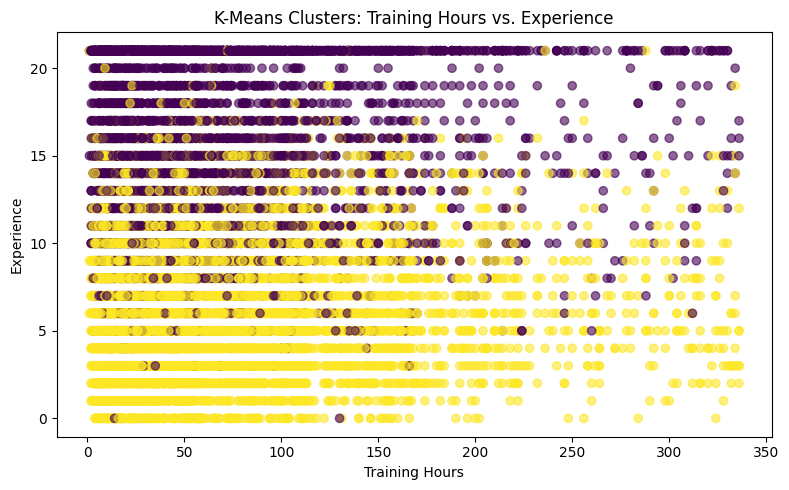

In [20]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["training_hours"],
    df["experience"],
    c=df["kmeans_cluster"],
    alpha=0.6
)

plt.xlabel("Training Hours")
plt.ylabel("Experience")
plt.title("K-Means Clusters: Training Hours vs. Experience")
plt.tight_layout()
plt.show()

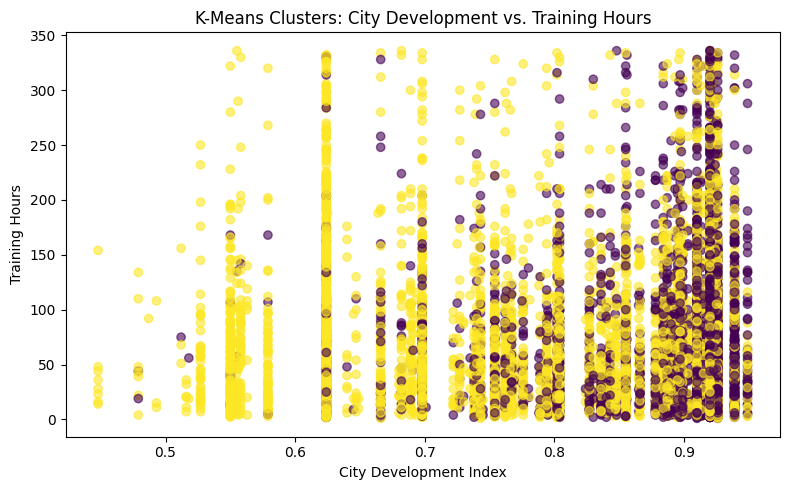

In [21]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["city_development_index"],
    df["training_hours"],
    c=df["kmeans_cluster"],
    alpha=0.6
)

plt.xlabel("City Development Index")
plt.ylabel("Training Hours")
plt.title("K-Means Clusters: City Development vs. Training Hours")
plt.tight_layout()
plt.show()

### K-Means Visualization

The two-dimensional scatter plots provide a simplified view of the candidate segments identified by K-Means.

Some overlap between clusters is expected because the clustering algorithm was trained using all selected features simultaneously, while each scatter plot displays only two features at a time.

Therefore, a lack of perfect visual separation in these plots does not necessarily indicate poor clustering. Instead, the plots help illustrate how individual features contribute to the broader multidimensional cluster structure.

## 4. Agglomerative Clustering

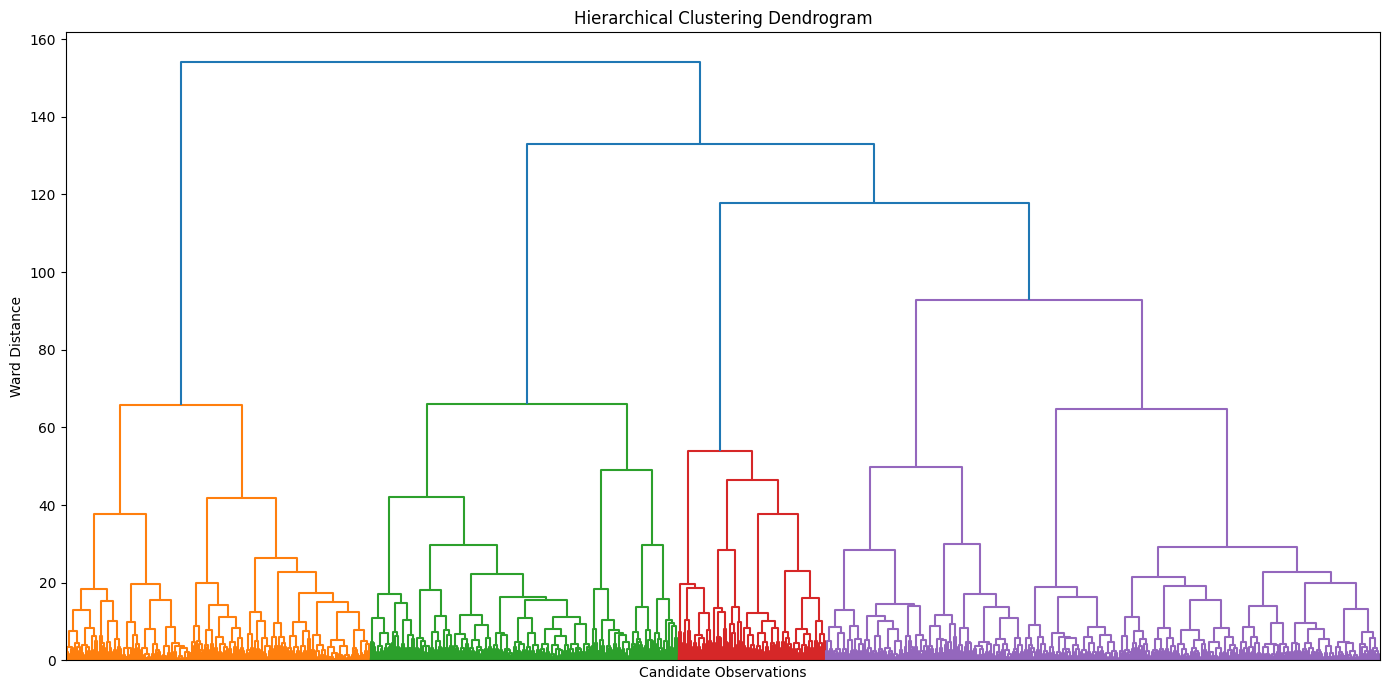

In [22]:
import scipy.cluster.hierarchy as sch

linkage_matrix = sch.linkage(
    X_scaled,
    method="ward"
)

plt.figure(figsize=(14, 7))

sch.dendrogram(
    linkage_matrix,
    no_labels=True
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Candidate Observations")
plt.ylabel("Ward Distance")
plt.tight_layout()
plt.show()

In [23]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(
    n_clusters=2,
    linkage="ward"
)

df["agg_cluster"] = agg.fit_predict(X_scaled)

print("Number of candidates in each Agglomerative cluster:")
display(
    df["agg_cluster"]
    .value_counts()
    .sort_index()
    .rename("Candidate Count")
    .to_frame()
)

Number of candidates in each Agglomerative cluster:


,Candidate Count
agg_cluster,
0,9966
1,3011


In [24]:
agg_silhouette = silhouette_score(
    X_scaled,
    df["agg_cluster"]
)

print(
    "Agglomerative Clustering Silhouette Score:",
    round(agg_silhouette, 3)
)

/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Agglomerative Clustering Silhouette Score: 0.205


/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


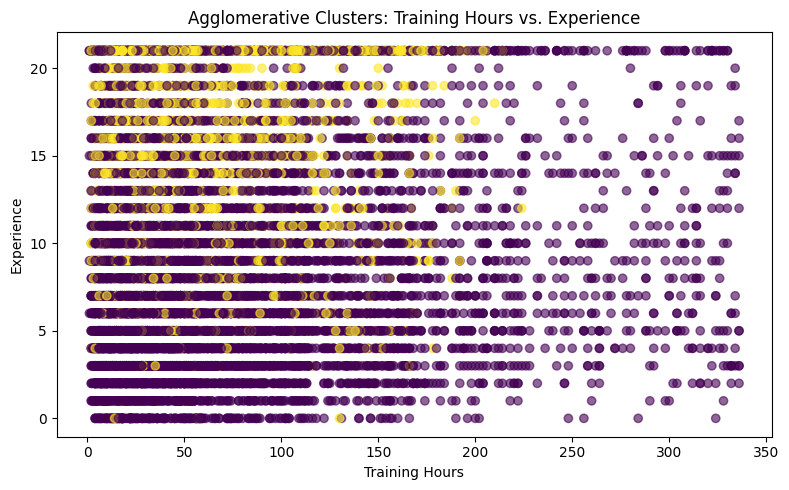

In [25]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["training_hours"],
    df["experience"],
    c=df["agg_cluster"],
    alpha=0.6
)

plt.xlabel("Training Hours")
plt.ylabel("Experience")
plt.title("Agglomerative Clusters: Training Hours vs. Experience")
plt.tight_layout()
plt.show()

### Agglomerative Cluster Visualization

The two Agglomerative clusters show some overlap when viewed using only training hours and experience.

There appears to be some separation based on experience, while training hours alone provides less distinction between the groups.

This overlap is not necessarily a weakness of the clustering solution because the algorithm uses all selected features simultaneously. A two-dimensional plot only shows a partial view of the full multidimensional cluster structure.

In [26]:
kmeans_2_silhouette = silhouette_score(
    X_scaled,
    df["kmeans_cluster"]
)

clustering_comparison = pd.DataFrame({
    "Method": [
        "K-Means",
        "Agglomerative Clustering"
    ],
    "Number of Clusters": [
        2,
        2
    ],
    "Silhouette Score": [
        kmeans_2_silhouette,
        agg_silhouette
    ]
})

display(clustering_comparison.round(3))

/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


,Method,Number of Clusters,Silhouette Score
0,K-Means,2,0.233
1,Agglomerative Clustering,2,0.205


### Clustering Method Comparison

K-Means and Agglomerative Clustering provide two different approaches to segmenting the candidate population.

K-Means creates clusters by minimizing distances to cluster centroids, while Agglomerative Clustering builds a hierarchy by progressively merging similar observations.

The silhouette scores provide a common measure for comparing the cohesion and separation of the two solutions. However, model selection should also consider whether the resulting candidate segments are interpretable and useful in the context of the dataset.